# Kishony–Fowler diagonal syndrome extraction: memory experiment

A rotated-surface-code memory experiment with the diagonal syndrome-extraction schedule of
Kishony and Fowler, *Surface code off-the-hook: diagonal syndrome-extraction scheduling*
([arXiv:2602.09099](https://arxiv.org/abs/2602.09099)).
The schedule is `DiagonalSurfaceCodeExtractionBlock` in
[`lightstim/qec_code/surface_code/rotated/diagonal_se.py`](https://github.com/John-YuehanZhang/CircLS/blob/main/lightstim/qec_code/surface_code/rotated/diagonal_se.py);
it is a drop-in replacement for the standard extraction block.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pymatching

from lightstim.ir.qec_system import QECSystem
from lightstim.ir.tracker import SyndromeTracker
from lightstim.ir.builder import CircuitBuilder
from lightstim.noise.config import NoiseConfig
from lightstim.qec_code.surface_code.rotated.code_patch import RotatedSurfaceCode
from lightstim.qec_code.surface_code.rotated.diagonal_se import DiagonalSurfaceCodeExtractionBlock


## 1. The memory experiment

Initialize every data qubit in the memory basis, run `d` rounds of the diagonal syndrome extraction,
and read out every data qubit in the same basis.  `CircuitBuilder` adds the detectors and the logical
observable.

In [2]:
def memory(d, basis, rounds=None):
    system = QECSystem()
    system.add_patch(RotatedSurfaceCode(distance=d), name="q")
    tracker = SyndromeTracker(num_qubits=system.num_qubits,
                              expected_num_logicals=system.num_logicals)
    builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=True)
    system.register_tracker(tracker)
    system.register_builder(builder)
    builder.write_coordinates()

    builder.initialize({q: basis for q in sorted(system.data_indices)}, n=system.num_qubits)
    se = DiagonalSurfaceCodeExtractionBlock(system)          # one noiseless round
    builder.apply_syndrome_extraction(se.circuit, rounds=rounds or d)
    builder.apply_data_readout({q: basis for q in sorted(system.data_indices)})
    return builder, se


## 2. One round of the schedule

One round resets the syndrome qubits, couples them to the data qubits over the 7 slots of the
paper's Fig. 4 table, and measures them.

In [3]:
builder, se = memory(3, "Z")
print("coupling slots:", se.coupling_slots)
print(se.circuit)


coupling slots: 7
R 0 4 5 6 10 11 12 16
TICK[SE_start]
H 0 6 12 16
TICK
CX 7 4 9 5 14 11
TICK
CX 2 4 7 10 9 11
TICK
CX 8 4 13 10 15 11
TICK
CX 1 4 3 5 6 2 8 11 12 7 16 14
TICK
CX 0 2 6 9 12 14
TICK
CX 6 3 12 8 16 15
TICK
CX 0 1 6 8 12 13
TICK
H 0 6 12 16
TICK
M 0 4 5 6 10 11 12 16


## 3. Detector slices

`circuit.diagram("detslice-with-ops-svg")` draws the d = 3 memory experiment tick by tick: the gates
of each tick and the detecting regions at that time.

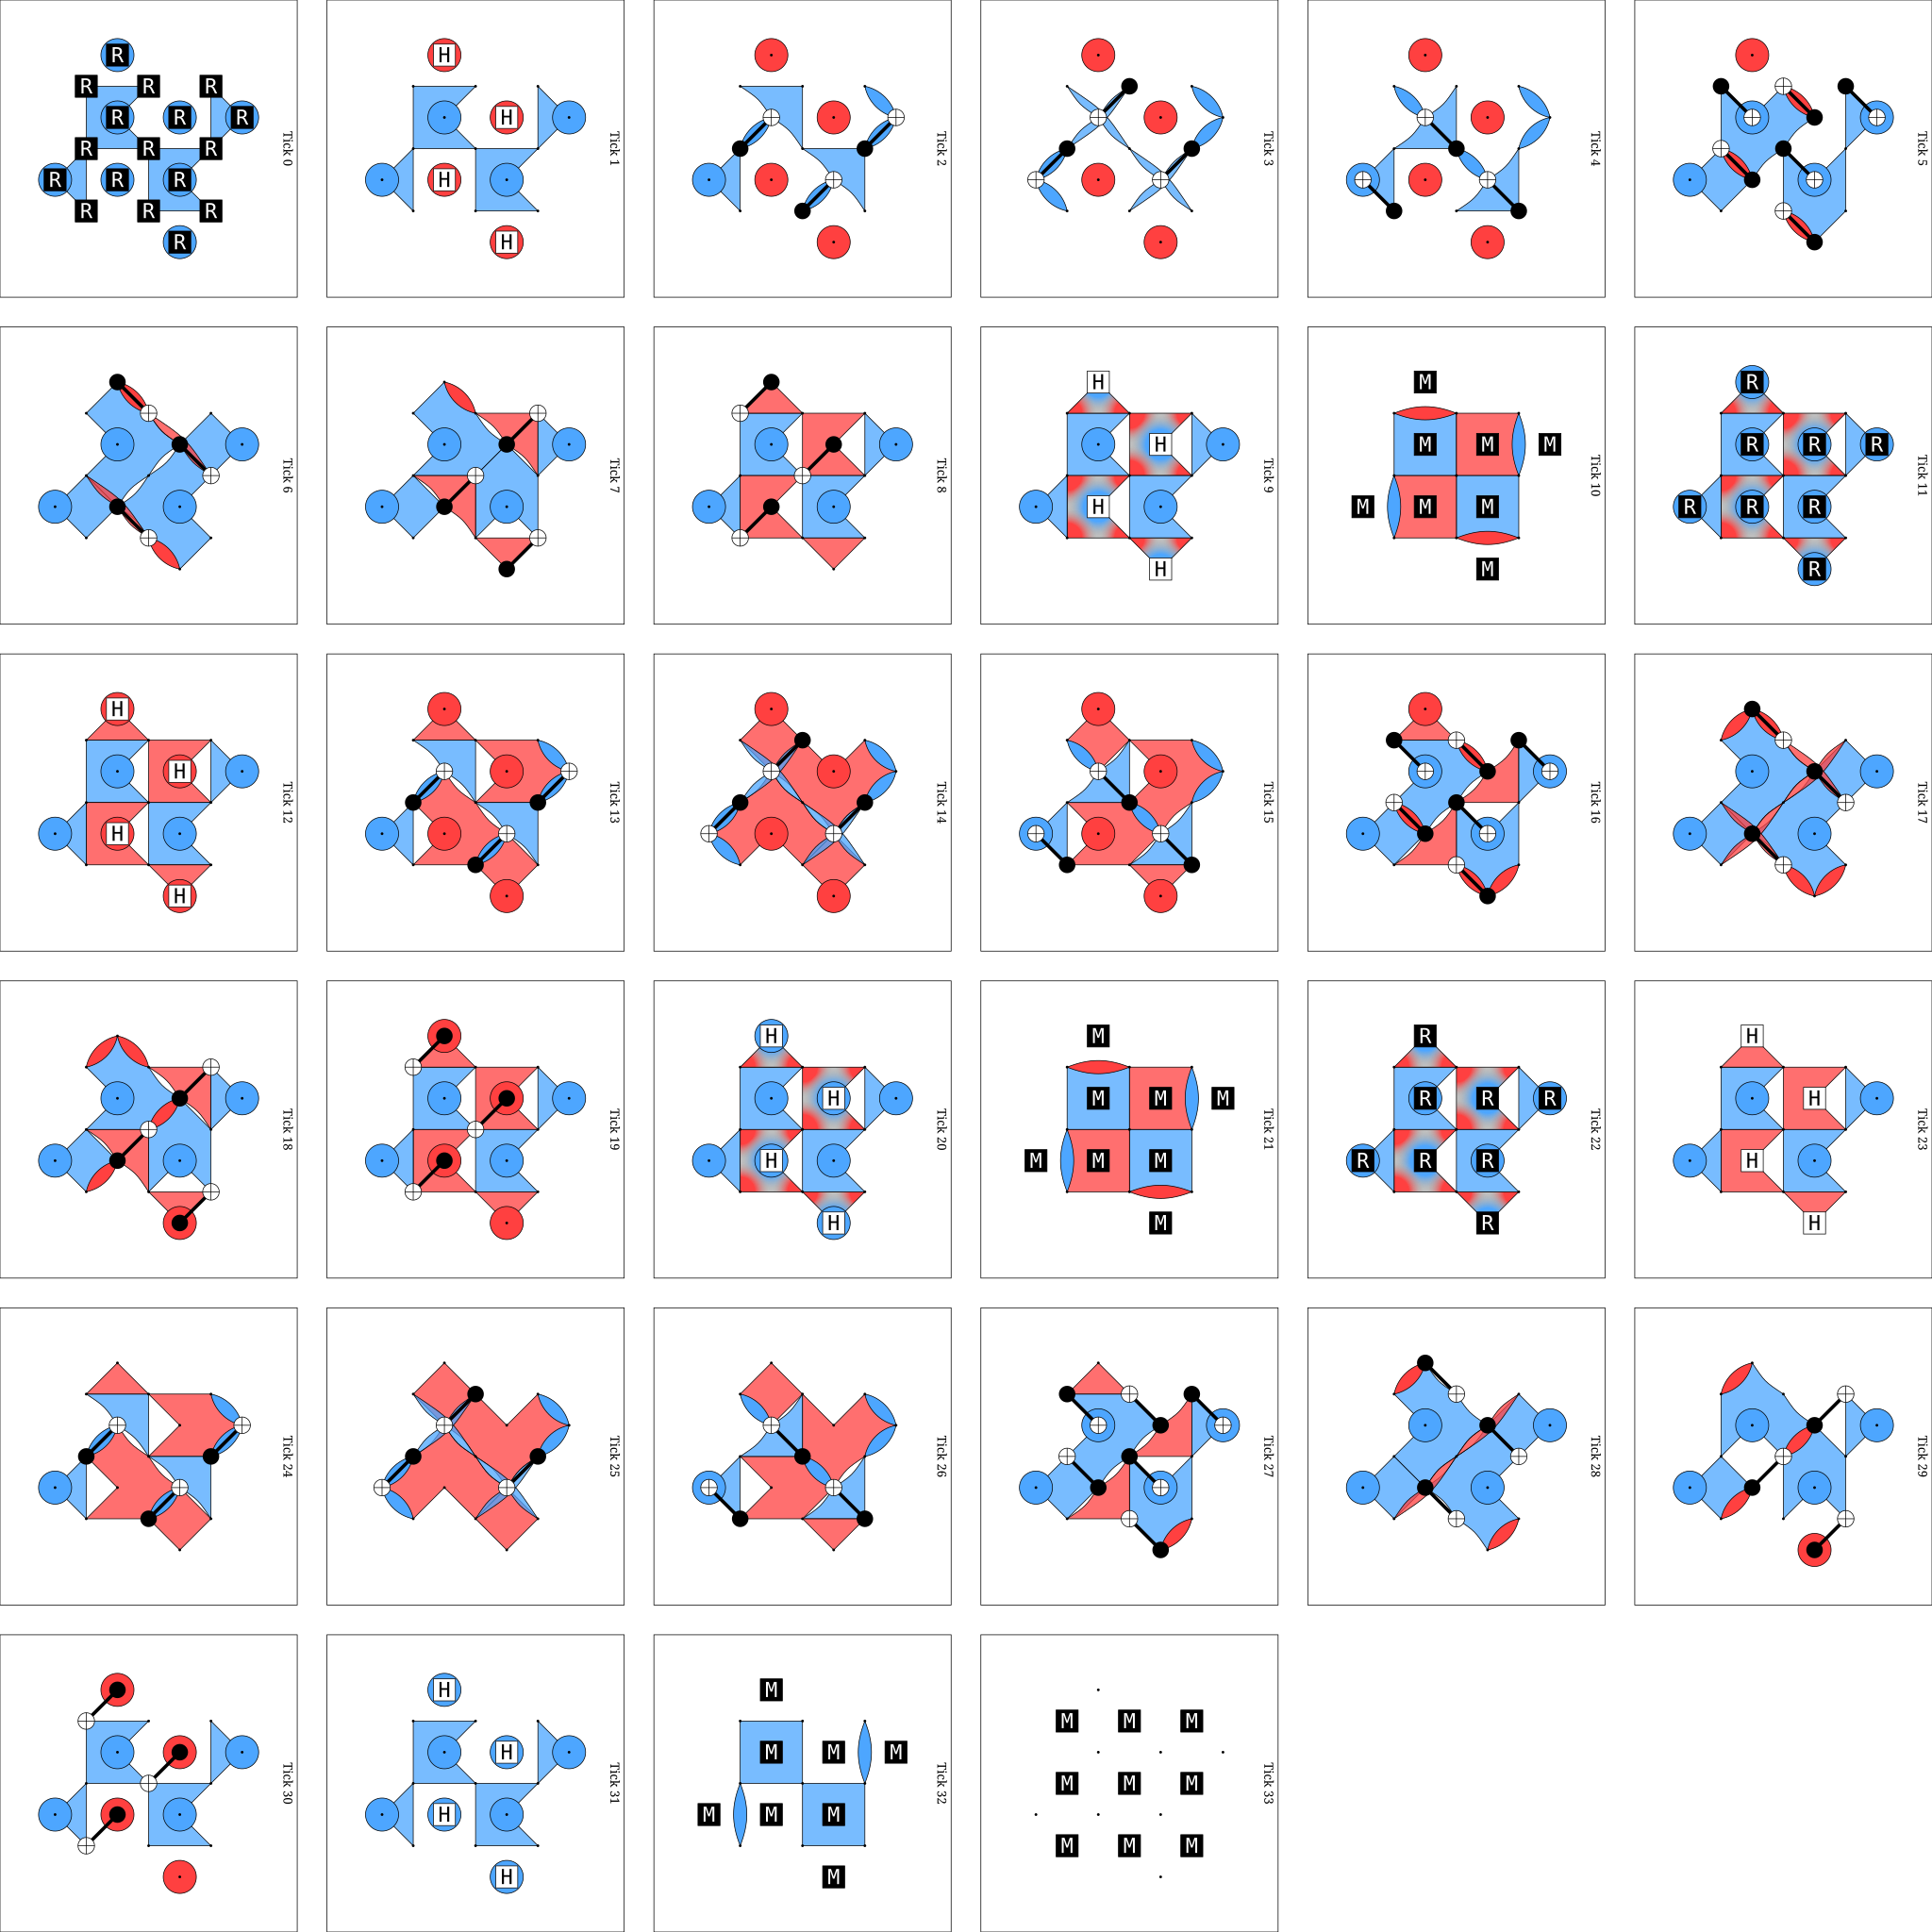

In [4]:
from IPython.display import SVG, display

builder, _ = memory(3, "Z")
display(SVG(str(builder.circuit.diagram("detslice-with-ops-svg"))))


## 4. Checks

At p = 0 no detector fires and the observable is deterministic.  Under circuit-level depolarizing
noise the shortest graphlike logical error has length `d` in both bases.

In [5]:
p = 1e-3
noise = NoiseConfig(p_1q=p, p_2q=p, p_meas=p, p_reset=p, p_idle=p)

for d in (3, 5, 7):
    for basis in ("X", "Z"):
        builder, _ = memory(d, basis)
        det, obs = builder.circuit.compile_detector_sampler(seed=0).sample(
            256, separate_observables=True)
        noisy = builder.build_noisy_circuit(noise_params=noise, noise_model="circuit_level")
        print(f"d={d} basis={basis}: {builder.circuit.num_detectors} detectors, "
              f"p=0 silent={not det.any()}, deterministic={not obs.any()}, "
              f"graphlike distance={len(noisy.shortest_graphlike_error())}")


d=3 basis=X: 24 detectors, p=0 silent=True, deterministic=True, graphlike distance=3
d=3 basis=Z: 24 detectors, p=0 silent=True, deterministic=True, graphlike distance=3
d=5 basis=X: 120 detectors, p=0 silent=True, deterministic=True, graphlike distance=5
d=5 basis=Z: 120 detectors, p=0 silent=True, deterministic=True, graphlike distance=5


d=7 basis=X: 336 detectors, p=0 silent=True, deterministic=True, graphlike distance=7
d=7 basis=Z: 336 detectors, p=0 silent=True, deterministic=True, graphlike distance=7


## 5. Logical error rate

Sample the noisy circuit and decode with PyMatching.

In [6]:
def logical_error_rate(circuit, shots, seed=0):
    """Sample the noisy circuit and decode with PyMatching; returns (errors, shots)."""
    dem = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(dem)
    det, obs = circuit.compile_detector_sampler(seed=seed).sample(shots, separate_observables=True)
    errors = int(np.any(matcher.decode_batch(det) != obs, axis=1).sum())
    return errors, shots

p = 2e-3
noise = NoiseConfig(p_1q=p, p_2q=p, p_meas=p, p_reset=p, p_idle=p)
for d in (3, 5, 7):
    builder, _ = memory(d, "Z")
    noisy = builder.build_noisy_circuit(noise_params=noise, noise_model="circuit_level")
    errors, shots = logical_error_rate(noisy, shots=200_000)
    print(f"p={p:g} d={d}: LER = {errors / shots:.2e} ({errors}/{shots})")


p=0.002 d=3: LER = 3.38e-03 (676/200000)


p=0.002 d=5: LER = 1.19e-03 (237/200000)


p=0.002 d=7: LER = 2.65e-04 (53/200000)
